In [22]:
%pip uninstall -y scikit-learn numpy scipy
%pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 umap-learn --no-cache-dir

Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\cli\base_command.py", line 160, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\commands\uninstall.py", line 103, in run
    uninstall_pathset.commit()
  File "c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 424, in commit
    self._moved_paths.commit()
  File "c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 277, in commit
    save_dir.cleanup()
  File "c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "c:\Users\Diya Budlakoti\AppDat

     --------------------------------------- 15.8/15.8 MB 13.1 MB/s eta 0:00:00
     ---------------------------------------- 10.6/10.6 MB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch

embedding_cache = torch.load("smiles_embeddings.pt")

In [24]:
import pandas as pd
df=pd.read_csv("C:\\Users\\Diya Budlakoti\\Desktop\\SIN_proj\\dataset\\final_processed_data.csv")

In [25]:
emb_s1 = torch.stack([embedding_cache[s] for s in df["SMILES1"]])
emb_s2 = torch.stack([embedding_cache[s] for s in df["SMILES2"]])

In [26]:
#combined_embeddings = torch.cat([emb_s1, emb_s2], dim=1)
combined_embeddings = torch.add(emb_s1, emb_s2)  

In [27]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Embedding shape: (63304, 768)


c:\Users\Diya Budlakoti\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (5000, 2)


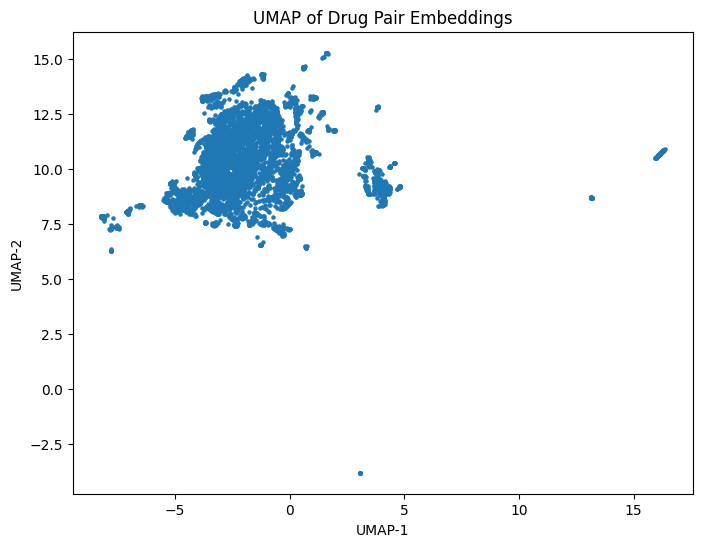

In [ ]:
import numpy as np
import pandas as pd
import torch
import umap
import matplotlib.pyplot as plt

# -------------------------------
# 1. Convert embeddings to numpy
# -------------------------------
emb_np = combined_embeddings.cpu().numpy()

print("Embedding shape:", emb_np.shape)

# -------------------------------
# 2. Sample data
# -------------------------------
sample_size = 10000
np.random.seed(42)
indices = np.random.choice(len(emb_np), sample_size, replace=False)

emb_sample = emb_np[indices]
labels_sample = df["Side Effect Name"].iloc[indices].values

# -------------------------------
# 3. Normalize (manual, no sklearn)
# -------------------------------
norms = np.linalg.norm(emb_sample, axis=1, keepdims=True)
emb_sample = emb_sample / (norms + 1e-10)

# -------------------------------
# 4. Apply UMAP
# -------------------------------
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=2,
    metric='cosine',
    random_state=42
)

emb_2d = reducer.fit_transform(emb_sample)

print("UMAP output shape:", emb_2d.shape)

# -------------------------------
# 5. Plot (no sklearn)
# -------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=5)
plt.title("UMAP of Drug Pair Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

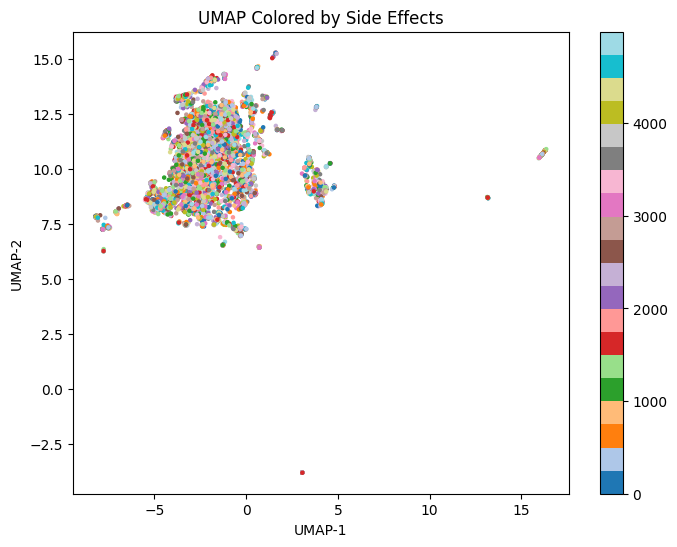

In [29]:
labels_sample = df["Side Effect Name"].iloc[indices].values
unique_labels = list(set(labels_sample))
label_map = {label: i for i, label in enumerate(unique_labels)}

labels_encoded = [label_map[l] for l in labels_sample]
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels_encoded,
    s=5,
    cmap='tab20'
)

plt.title("UMAP Colored by Side Effects")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar()
plt.show()